In [36]:
%cd ..

C:\Users\apietka\PycharmProjects\accur8pool


In [7]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Import danych

In [38]:
raw = pd.read_csv(r'.\data\raw_data\28042026\data20260428_183042.csv')
prepared = pd.read_csv(r'.\data\prepared\data20260428_183042.csv')
labels =  pd.read_csv(r'.\data\labeled\data20260428_183042.csv')
labels = labels
labels.fillna(value=0,inplace=True)
combined_raw_labels = pd.concat([raw,labels],axis=1)
combined_prepared_labels = pd.concat([prepared,labels],axis=1)

In [40]:
data_columns = ['accx', 'accy', 'accz', 'gyrx', 'gyry', 'gyrz', 'magx', 'magy', 'magz',
       'linaccx', 'linaccy', 'linaccz', 'rotx', 'roty', 'rotz',
       'acc_magnitude', 'gyr_magnitude','jerk_accx', 'jerk_accy',
       'jerk_accz', 'acc_magnitude_jerk', 'jerk_gyrx', 'jerk_gyry',
       'jerk_gyrz', 'gyr_magnitude_jerk', 'roll', 'pitch']
label_column = 'label'

# Wykresy

## Surowe dane z przypisanymi etykietami.
    W tej formie trudno bezpośrednio zauważyć powtarzalne wzorce i zależności w sygnale. Na ziolono są zaznaczone momenty w ktorym wystapilo udrzenie

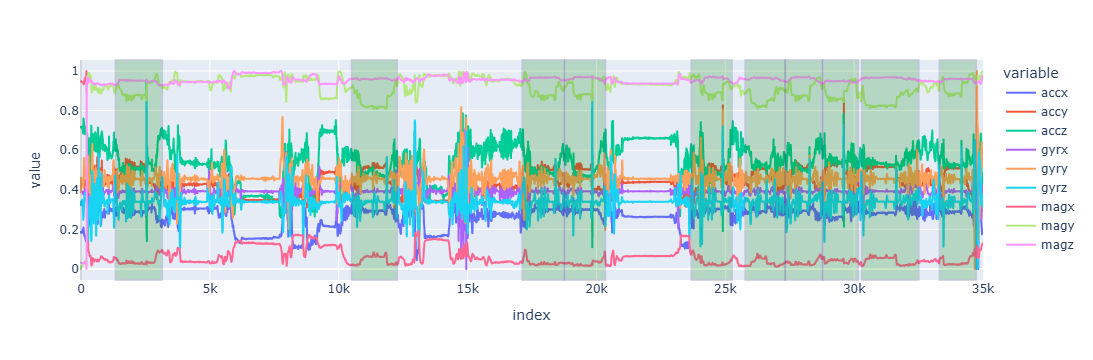

In [49]:
stop_idx= 35000
fig=px.line(scaled_df.loc[:stop_idx,['accx', 'accy', 'accz', 'gyrx', 'gyry', 'gyrz', 'magx', 'magy', 'magz']])
lables_segments = combined_prepared_labels.groupby('label_id').agg(label=('label','first'),start_idx = ('start_idx','min'),stop_idx=('end_idx','max'))

for _,segment in lables_segments.iterrows():
    if stop_idx < segment['stop_idx']:
        break
    fig.add_vrect(x0=segment['start_idx'],x1=segment['stop_idx'],fillcolor='green',opacity=0.2)
fig

# Skalowanie min max danych w celu lepszej prezentacji wykresów

In [5]:
scaled_df = (combined_prepared_labels - combined_prepared_labels.min())/ (combined_prepared_labels.max()-combined_prepared_labels.min())

# Przetworzone dane z przypisanymi etykietam.
    Zostały stworzone nowe kolumny pozwalając na lepsze obserwacje sygnału

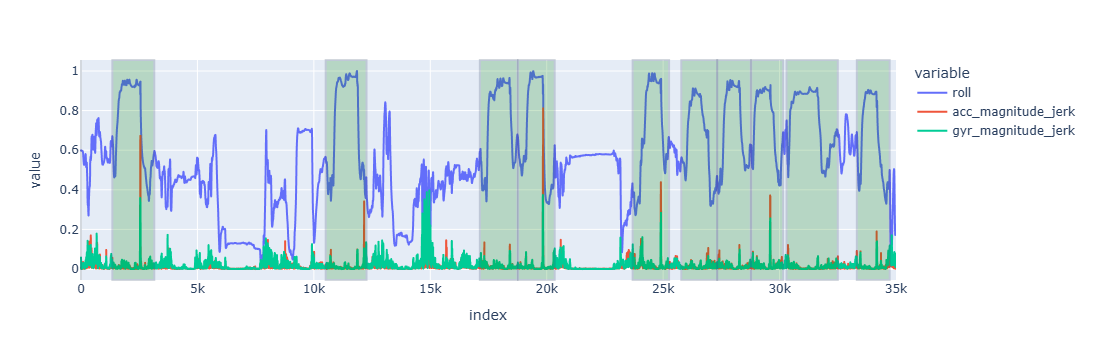

In [6]:
stop_idx= 35000
fig = px.line(scaled_df.loc[:stop_idx,['roll','acc_magnitude_jerk','gyr_magnitude_jerk']])
lables_segments = combined_prepared_labels.groupby('label_id').agg(label=('label','first'),start_idx = ('start_idx','min'),stop_idx=('end_idx','max'))

for _,segment in lables_segments.iterrows():
    if stop_idx < segment['stop_idx']:
        break
    fig.add_vrect(x0=segment['start_idx'],x1=segment['stop_idx'],fillcolor='green',opacity=0.2)
fig

# Korelacje danych względem label

    

## Violinplot
    Rysowanie wykresów violinplot w celu analizy rozkładu danych oraz identyfikacji wstępnych zależności między cechami a występowaniem etykiety 0 lub 1 w określonych fragmentach sygnału.

    Obserwacje:

        Akcelerometr – dla etykiety 1 obserwowane są większe wartości skrajne, co może wskazywać na występowanie bardziej dynamicznych ruchów. Jednocześnie większość wartości koncentruje się wokół mediany, co sugeruje obecność zarówno faz stabilnych, jak i epizodów intensywnej aktywności.
    
        Żyroskop – dane dla etykiety 1 wykazują większą stabilność w zakresie prędkości kątowych, szczególnie widoczną w osi X. Może to sugerować bardziej uporządkowany lub mniej chaotyczny ruch obrotowy.
    
    Magnetometr – sygnały z magnetometru są częściowo skorelowane z żyroskopem, co przekłada się na podobny ogólny wzorzec.
    
        Jerk – cechy typu jerk są silnie powiązane z akcelerometrem i pokazują dynamikę zmian sygnału. Dla etykiety 1 obserwuje się wyraźniejszą strukturę w tych zmiennych, szczególnie w osiach X i Y, co może wskazywać na bardziej charakterystyczne wzorce nagłych zmian ruchu.

        Dane nie wykazują błedów lub nierealnych wartości w outlierach

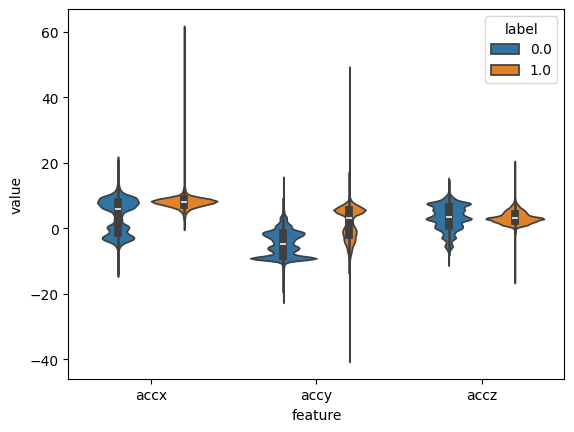

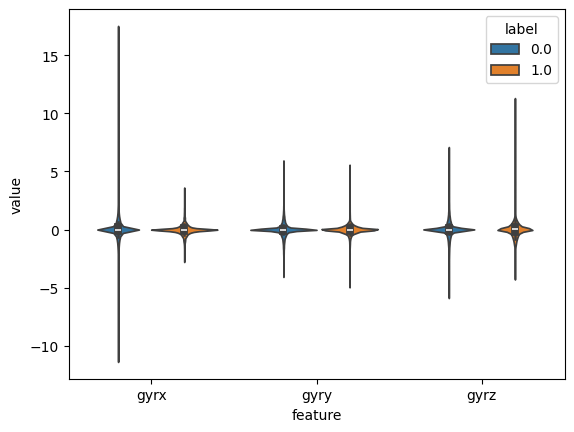

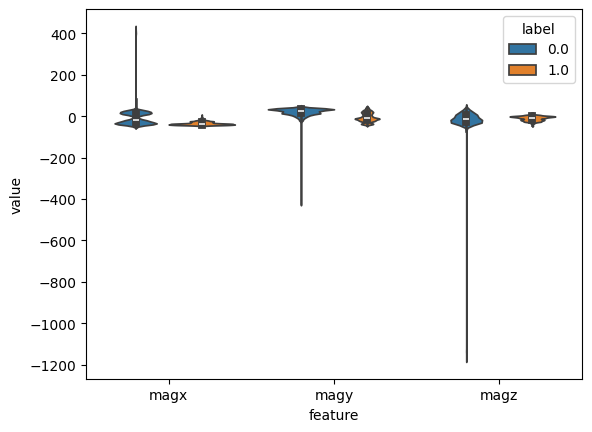

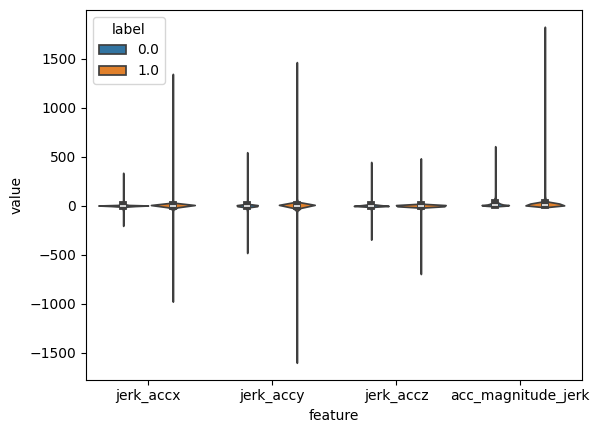

In [17]:
acc_cols = ['accx', 'accy', 'accz']
gyr_cols = ['gyrx', 'gyry', 'gyrz']
mag_cols = ['magx', 'magy', 'magz']
jerk_cols =['jerk_accx', 'jerk_accy','jerk_accz', 'acc_magnitude_jerk']
plot_cols = [acc_cols,gyr_cols,mag_cols,jerk_cols]

for cols in plot_cols:
    tmp=combined_prepared_labels.melt(
    id_vars="label",
    value_vars=cols,
    var_name="feature",
    value_name="value"
    )
    sns.violinplot(tmp,x='feature',y='value',hue='label')
    plt.show()


## Korelacja cech z etykietą

Współczynniki korelacji Pearsona między każdą cechą a `label`.

Najsilniej z etykietą wiążą się `roll` (0,63), `accy` (0,59), `pitch` (−0,45),
`accx` (0,45) oraz `magx` i `magy` (ok. −0,40). Bliskie zeru są wszystkie osie
żyroskopu, przyspieszenie liniowe i cechy `jerk_*`.

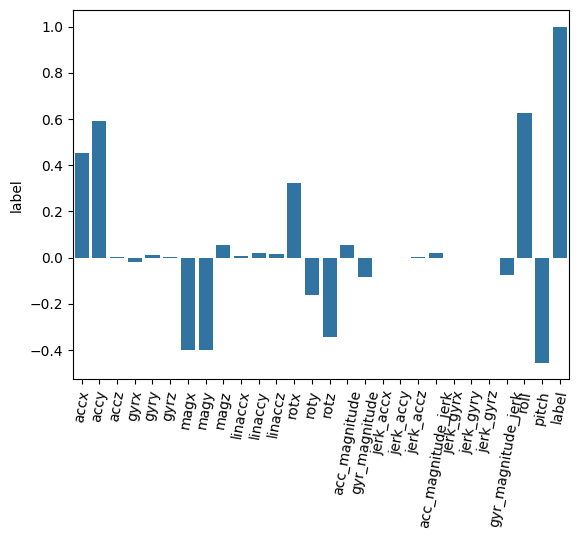

In [33]:
corr=combined_prepared_labels[data_columns+['label']].corr()['label']
sns.barplot(corr)
plt.xticks(rotation=80)
plt.show()